# **1. Dataset:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load and visualize data:
print("WALMART SALES FORECAST")
print("="*80)
df = pd.read_csv("../data/Walmart.csv")

print("\n Dataset Overview")
df.info()

WALMART SALES FORECAST

 Dataset Overview
<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [3]:
# Convert data
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Data dimension Verification:
print("\n" + "="*80)
print("DATA DIMENSION")
print("="*80)
print(f"Total number of stores: {df['Store'].nunique()}")
print(f"Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total weeks: {df['Date'].nunique()}")
print(f"Total records: {len(df):,}")
print(f"Total records per store (avg): {len(df) / df['Store'].nunique():.1f}")

# Missing data check:
missing_values = df.isnull().sum()
print("\nMissing Values:")
print(missing_values[missing_values >0] if missing_values.sum() > 0 else "No missing values found!")

# Analysis constants:
TEST_SIZE = 13      # Last 13 Weeks for testing
SEASONAL_PERIOD = 13 # Quarterly seasonality 


DATA DIMENSION
Total number of stores: 45
Date range: 2010-02-05 to 2012-10-26
Total weeks: 143
Total records: 6,435
Total records per store (avg): 143.0

Missing Values:
No missing values found!


# **2. Correlation and Variance Explained by External Factors**


CORRELATION ANALYSIS - External Factors Impact

Correlation with Weekly Sales:
  • Holiday_Flag        : +0.0369
  • Fuel_Price          : +0.0095
  • Temperature         : -0.0638
  • CPI                 : -0.0726
  • Unemployment        : -0.1062


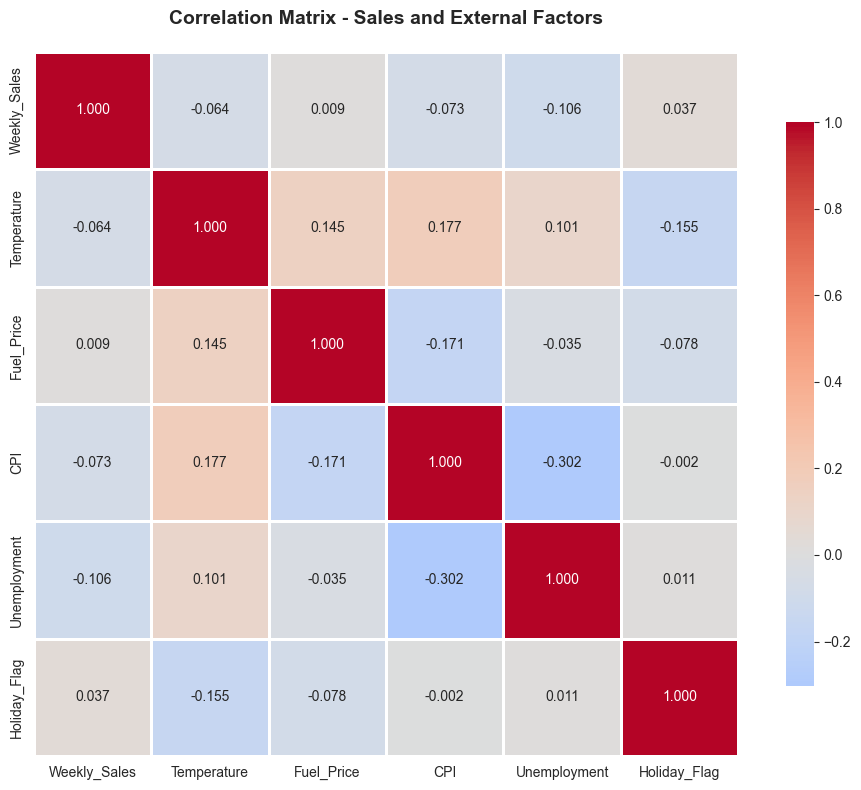

In [4]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS - External Factors Impact")
print("="*80)

# Calculate correlations
correlation_features = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']
correlation_df = df[correlation_features].corr()

print("\nCorrelation with Weekly Sales:")
sales_corr = correlation_df['Weekly_Sales'].sort_values(ascending=False)
for feature, corr_value in sales_corr.items():
    if feature != 'Weekly_Sales':
        print(f"  • {feature:20s}: {corr_value:+.4f}")

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_df,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix - Sales and External Factors', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

- External factors such as Fuel Price, CPI, Temperature, and Unemployment show very weak correlations with Weekly Sales. 

- Holiday_Flag has a small positive correlation, meaning sales tend to rise slightly during holiday weeks. 

- The heatmap confirms that no external variable has strong linear influence on weekly sales, suggesting that seasonality, promotions, and store-level effects likely drive most variation.

In [5]:
print("="*80)
print("VARIANCE - External Fators Impact")
print("="*80)

# Temperature variance explanation (R-squared)
X_temp = df[['Temperature']].dropna()
y_sales = df.loc[X_temp.index, 'Weekly_Sales']

temp_model = LinearRegression()
temp_model.fit(X_temp, y_sales)
r2_temp = temp_model.score(X_temp, y_sales)

print(f"• Temperature R² Score: {r2_temp:.4f} ({r2_temp*100:.2f}% of variance explained)")

# Multiple regression with all features
X_multi = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']].dropna()
y_multi = df.loc[X_multi.index, 'Weekly_Sales']

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)
r2_multi = multi_model.score(X_multi, y_multi)

print(f"• All Features R2 Score: {r2_multi:.4f} ({r2_multi*100:.2f}% of variance explained)")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Importance (Coefficients):")
for _, row in feature_importance.iterrows():
    print(f"  • {row['Feature']:20s}: {row['Coefficient']:+,.2f}")


VARIANCE - External Fators Impact
• Temperature R² Score: 0.0041 (0.41% of variance explained)
• All Features R2 Score: 0.0254 (2.54% of variance explained)

Feature Importance (Coefficients):
  • Holiday_Flag        : +74,891.66
  • Temperature         : -724.17
  • CPI                 : -1,598.87
  • Fuel_Price          : -10,167.88
  • Unemployment        : -41,552.28


* **Temperature alone explains almost none of the variation** in Weekly Sales (R² ≈ 0.004 → 0.41%).
* Using **all external features together** still explains only about **2.5% of sales variance**, confirming that these factors have very limited predictive power.
* The coefficient table shows the direction of influence, but the **overall impact remains weak**, meaning weekly sales are driven mainly by **store-specific patterns, seasonality, holidays, and promotions**, not these external variables.

# 3. **Store-wise Analysis and Sales Distribution**


STORE-WISE ANALYSIS

Top 10 Stores by Total Sales:
   1. Store 20: $301,397,792
   2. Store  4: $299,543,953
   3. Store 14: $288,999,911
   4. Store 13: $286,517,704
   5. Store  2: $275,382,441
   6. Store 10: $271,617,714
   7. Store 27: $253,855,917
   8. Store  6: $223,756,131
   9. Store  1: $222,402,809
  10. Store 39: $207,445,542


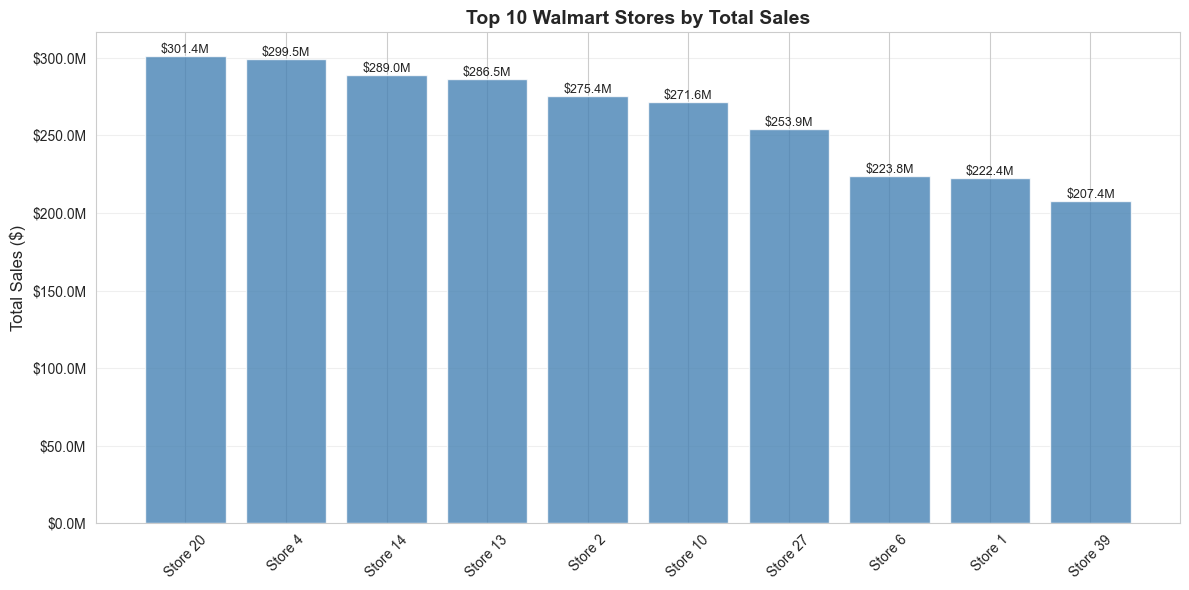

In [ ]:
print("\n" + "="*80)
print("STORE-WISE ANALYSIS")
print("="*80)

# Total sales by store
store_total_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
print(f"\nTop 10 Stores by Total Sales:")
for i, (store, sales) in enumerate(store_total_sales.head(10).items(), 1):
    print(f"  {i:2d}. Store {store:2d}: ${sales:,.0f}")

# Visualize top 10 stores
plt.figure(figsize=(12, 6))
top_10_stores = store_total_sales.head(10)
bars = plt.bar(range(len(top_10_stores)), top_10_stores.values, color='steelblue', alpha=0.8)
plt.xticks(range(len(top_10_stores)), [f"Store {s}" for s in top_10_stores.index], rotation=45)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.title('Top 10 Walmart Stores by Total Sales', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e6):.1f}M'))

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'${height/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

* The top-performing stores generate around **$300M** in total sales, showing strong variation across locations.
* Stores 20, 4, 14, and 13 lead the dataset with the highest cumulative sales.
* The bar chart highlights how **only a few stores contribute disproportionately** to total revenue, indicating uneven sales distribution across the network.


Plotting sales trends for top 5 stores


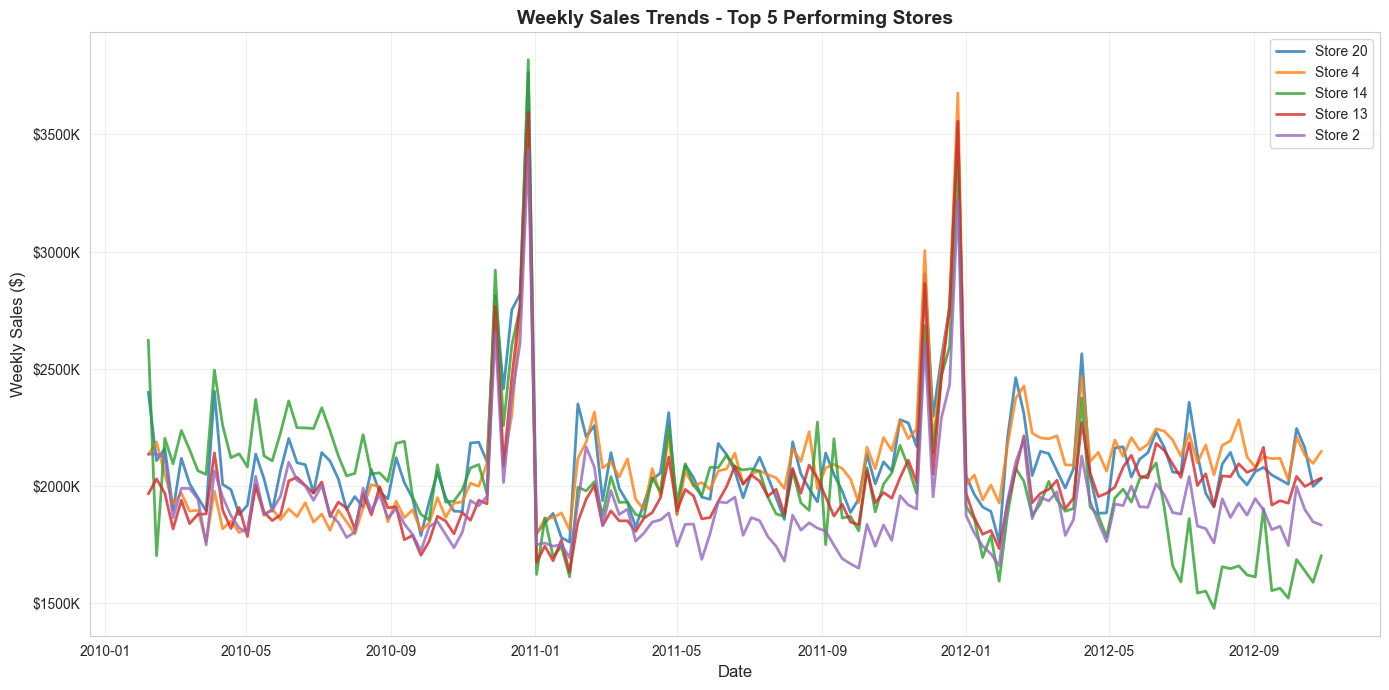

In [98]:
# Store-wise sales over time (top 5 stores)
print("\nPlotting sales trends for top 5 stores")
df_indexed = df.set_index('Date')
top_5_stores = store_total_sales.head(5).index

plt.figure(figsize=(14, 7))
for store in top_5_stores:
    store_data = df_indexed[df_indexed['Store'] == store]['Weekly_Sales'].resample('W').sum()
    plt.plot(store_data.index, store_data.values, label=f'Store {store}', linewidth=2, alpha=0.8)

plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Weekly Sales Trends - Top 5 Performing Stores', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* All top-performing stores show **strong weekly fluctuations**, which is typical in retail sales.
* Noticeable **spikes around holiday periods** (e.g., late 2010, late 2011) indicate seasonal demand surges.
* Despite fluctuations, the top stores follow **similar overall patterns**, suggesting consistent seasonal and promotional effects across locations.


1. Sales Distribution Analysis


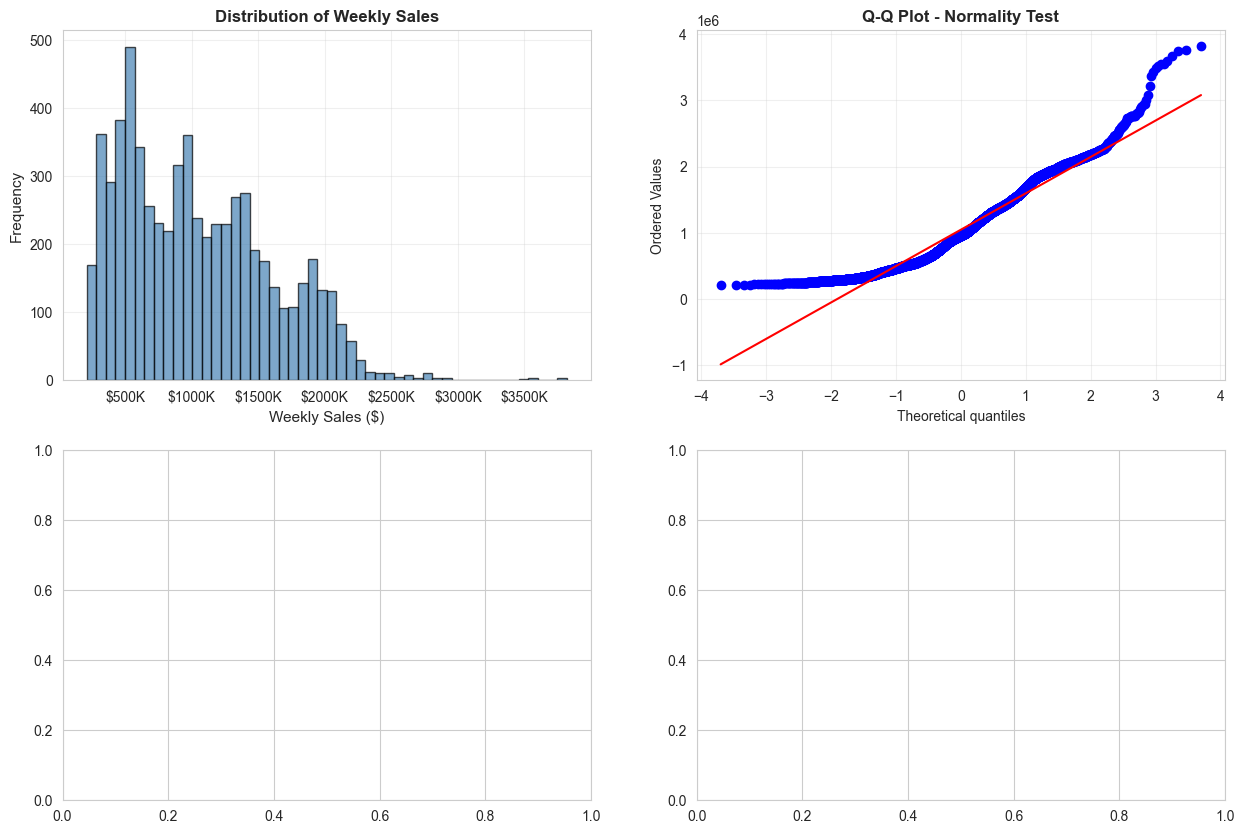

In [139]:
# 1. Sales Distribution Analysis
print("\n1. Sales Distribution Analysis")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram with KDE
axes[0, 0].hist(df['Weekly_Sales'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Weekly Sales ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Weekly Sales', fontweight='bold', fontsize=12)
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
axes[0, 0].grid(alpha=0.3)

# Q-Q Plot for normality
from scipy import stats
stats.probplot(df['Weekly_Sales'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot - Normality Test', fontweight='bold', fontsize=12)
axes[0, 1].grid(alpha=0.3)
